# 01 - Mass Breakdown

This notebook examines the component-level mass breakdown of the Archer Midnight. Mass estimation uses a combination of parametric models (NDARC-based regressions, Raymer, and Hoerner) and fixed inputs from the JSON configuration.

## Mass Estimation Approach

`evtolpy` divides mass components into three categories:

| Category | Components | Method |
|---|---|---|
| **Structural** | Wing, fuselage, boom, tails, landing gear 
| **Propulsion** | EPU motors, lift rotor hubs, rotors
| **Fixed** | Avionics, actuators, ECS, furnishings, power distribution (Direct input from JSON)

Also, **battery mass** is sized from total mission energy requirements, and a **mass margin factor** is applied to the calculated empty weight.

The total MTOW is:

$$MTOW = \underbrace{(1 + f_{margin})}_{\text{margin}} \cdot \underbrace{(m_{struct} + m_{prop} + m_{fixed})}_{\text{empty mass}} + m_{battery} + m_{payload}$$

In [ ]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../Archer_Midnight.json')

## Structural Mass Components

These masses are estimated from parametric models that scale with aircraft geometry and MTOW. The models are adapted from NASA's NDARC and Raymer estimations. Since these masses change with MTOW, they are apart of the MTOW loop.

In [14]:
structural = {
    'Wing':               aircraft.wing_mass_kg,
    'Horizontal Tail':    aircraft.horiz_tail_mass_kg,
    'Vertical Tail':      aircraft.vert_tail_mass_kg,
    'Fuselage':           aircraft.fuselage_mass_kg,
    'Boom':               aircraft.boom_mass_kg,
    'Landing Gear':       aircraft.landing_gear_mass_kg,
}

print(f"{'Component':<25s} {'Mass (kg)':>10s}")
print("-" * 36)
for name, mass in structural.items():
    print(f"{name:<25s} {mass:>10.2f}")
print("-" * 36)
print(f"{'Structural Total':<25s} {sum(structural.values()):>10.2f}")

Component                  Mass (kg)
------------------------------------
Wing                          319.54
Horizontal Tail                24.17
Vertical Tail                  22.57
Fuselage                      131.36
Boom                          155.85
Landing Gear                  127.04
------------------------------------
Structural Total              780.54


## Propulsion Mass Components

Propulsion masses are estimated from NDARC based regressions. The EPU (Electric Propulsion Unit) mass per motor is derived from hover torque, an over-torque factor (accounting for OEI conditions), and maximum RPM. Rotor blade and hub masses scale with disk loading and rotor diameter.

In [15]:
propulsion = {
    'EPU (all rotors)':       aircraft.epu_mass_kg,
    'Lift Rotor + Hub':       aircraft.lift_rotor_hub_mass_kg,
    'Tilt Rotor':             aircraft.tilt_rotor_mass_kg,
}

print(f"{'Component':<25s} {'Mass (kg)':>10s}")
print("-" * 36)
for name, mass in propulsion.items():
    print(f"{name:<25s} {mass:>10.2f}")
print("-" * 36)
print(f"{'Propulsion Total':<25s} {sum(propulsion.values()):>10.2f}")

Component                  Mass (kg)
------------------------------------
EPU (all rotors)              363.30
Lift Rotor + Hub               48.36
Tilt Rotor                     52.90
------------------------------------
Propulsion Total              464.57


## Subsystem and Fixed Mass Components

In [16]:
subsystems = {
    'Actuators':              aircraft.actuator_mass_kg,
    'Furnishings':            aircraft.furnishings_mass_kg,
    'Env. Control System':    aircraft.environmental_control_system_mass_kg,
    'Avionics':               aircraft.avionics_mass_kg,
    'Hi-Volt Power Dist.':    aircraft.hivolt_power_dist_mass_kg,
    'Lo-Volt Power & Comms':  aircraft.lovolt_power_coms_mass_kg,
}

print(f"{'Component':<25s} {'Mass (kg)':>10s}")
print("-" * 36)
for name, mass in subsystems.items():
    print(f"{name:<25s} {mass:>10.2f}")
print("-" * 36)
print(f"{'Subsystems Total':<25s} {sum(subsystems.values()):>10.2f}")

Component                  Mass (kg)
------------------------------------
Actuators                      69.60
Furnishings                    67.00
Env. Control System            40.00
Avionics                       60.00
Hi-Volt Power Dist.            80.00
Lo-Volt Power & Comms          60.00
------------------------------------
Subsystems Total              376.60


## Total Empty Mass and Battery

The empty mass includes all structural, propulsion, and subsystem components, including the mass fraction applied. The battery mass is sized from total mission energy requirements or the peak mission power requirement. Adding the empty weight, battery weight, and payload weight gives the full MTOW.

For an eVTOL the battery typically represents 30-40% of MTOW, which is much higher than fuel fraction for a conventional aircraft. This is due to primarily to the lower specific energy of batteries (current day ~250 Wh/kg) compared to jet fuel (~12,000 Wh/kg). This is why many articles aim for an eVTOL adoption around ~2050 to  allow for battery technology to reach ~500 Wh/kg.

In [17]:
print(f"Empty Mass:    {aircraft.empty_mass_kg:.2f} kg")
print(f"Battery Mass:  {aircraft.battery_mass_kg:.2f} kg")
print(f"Payload Mass:  {aircraft.payload_kg:.2f} kg")
print(f"")
print(f"MTOW:          {aircraft.max_takeoff_mass_kg:.2f} kg")
print(f"")
print(f"Empty fraction:   {aircraft.empty_mass_kg/aircraft.max_takeoff_mass_kg:.1%}")
print(f"Battery fraction: {aircraft.battery_mass_kg/aircraft.max_takeoff_mass_kg:.1%}")
print(f"Payload fraction: {aircraft.payload_kg/aircraft.max_takeoff_mass_kg:.1%}")

Empty Mass:    1702.79 kg
Battery Mass:  402.07 kg
Payload Mass:  454.00 kg

MTOW:          3175.00 kg

Empty fraction:   53.6%
Battery fraction: 12.7%
Payload fraction: 14.3%


## Visualize the Mass Breakdown

The bar chart shows every component. The pie chart groups them into high level categories to show which category dominates.

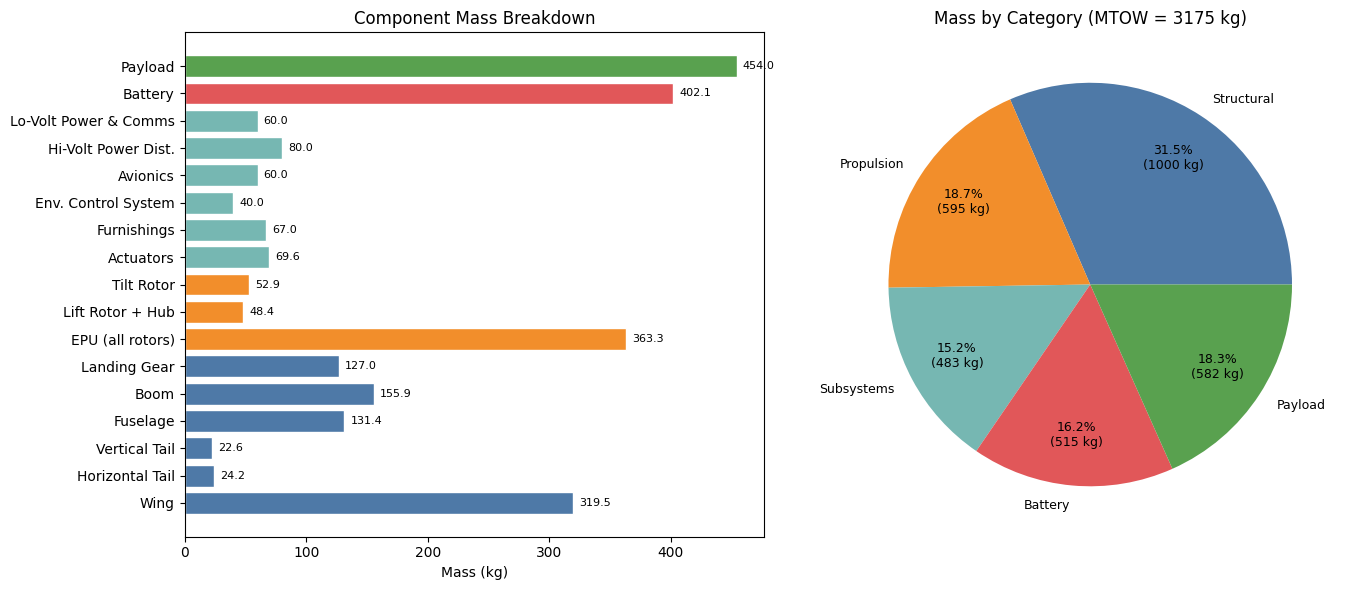

In [18]:
import matplotlib.pyplot as plt

all_components = {}
all_components.update(structural)
all_components.update(propulsion)
all_components.update(subsystems)
all_components['Battery'] = aircraft.battery_mass_kg
all_components['Payload'] = aircraft.payload_kg

names = list(all_components.keys())
masses = list(all_components.values())

# Color-code by category
comp_colors = []
for name in names:
    if name in structural:
        comp_colors.append('#4e79a7')
    elif name in propulsion:
        comp_colors.append('#f28e2b')
    elif name in subsystems:
        comp_colors.append('#76b7b2')
    elif name == 'Battery':
        comp_colors.append('#e15759')
    else:
        comp_colors.append('#59a14f')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - all components
bars = axes[0].barh(names, masses, color=comp_colors, edgecolor='white')
axes[0].set_xlabel('Mass (kg)')
axes[0].set_title('Component Mass Breakdown')
for bar, mass in zip(bars, masses):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{mass:.1f}', va='center', fontsize=8)

# Pie chart - category totals
cat_names = ['Structural', 'Propulsion', 'Subsystems', 'Battery', 'Payload']
cat_masses = [sum(structural.values()), sum(propulsion.values()),
              sum(subsystems.values()), aircraft.battery_mass_kg, aircraft.payload_kg]
cat_colors = ['#4e79a7', '#f28e2b', '#76b7b2', '#e15759', '#59a14f']
wedges, texts, autotexts = axes[1].pie(
    cat_masses, labels=cat_names, autopct=lambda p: f'{p:.1f}%\n({p*aircraft.max_takeoff_mass_kg/100:.0f} kg)',
    colors=cat_colors, pctdistance=0.75, textprops={'fontsize': 9}
)
axes[1].set_title(f'Mass by Category (MTOW = {aircraft.max_takeoff_mass_kg:.0f} kg)')

plt.tight_layout()
plt.show()

## Summary

The mass breakdown reveals the dominant weight contributors:

- **Battery** is typically one of the largest mass component (30-40% of MTOW), driven by the low specific energy of current battery technology
- **Payload** is a fixed design requirement, the aircraft must carry this regardless of other sizing outcomes
- **Structural** components are estimated from parametric models that scale with MTOW, creating the circular dependency that requires iteration
- **Propulsion** components use NDARC based regressions tied to the power and RPM needed
- **Subsystems** are fixed inputs

The relative proportion of the battery reveals why eVTOLs aren't comercially viable yet, batteries simply aren't good enough current day.

**Next:** [02 - MTOW Iteration]